In [1]:
import pandas as pd
import numpy as np
import math, sys
from sklearn.metrics import make_scorer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.kernel_ridge import KernelRidge
from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin, clone
from sklearn.linear_model import ElasticNet, Lasso,  BayesianRidge, LassoLarsIC
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve, KFold
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Input, Dense, LeakyReLU, Flatten, BatchNormalization
from tensorflow.keras.models import Model, Sequential, model_from_json
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from xgboost import XGBRegressor
from IPython.display import display
from itertools import product
from scipy import stats
from scipy.special import boxcox1p, inv_boxcox1p
from scipy.stats import norm, skew
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

pd.set_option('display.max_rows', 20)
df = pd.read_csv("train.csv")
columns_to_ignore = ['Id']
df.drop(columns=columns_to_ignore, inplace=True)
y_label = 'SalePrice'
df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [63]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotFrontage_missing,FireplaceQu_missing,LotFrontage_mean,FireplaceQu_mode
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,2,2008,WD,Normal,208500,False,True,65.0,Gd
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,5,2007,WD,Normal,181500,False,False,80.0,TA
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,9,2008,WD,Normal,223500,False,False,68.0,TA
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,2,2006,WD,Abnorml,140000,False,False,60.0,Gd
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,12,2008,WD,Normal,250000,False,False,84.0,TA


In [8]:
missing = pd.DataFrame(df.isna().sum(), columns=["cnt"])
missing[missing["cnt"] > 0]

,cnt
LotFrontage,259
Alley,1369
MasVnrType,8
MasVnrArea,8
BsmtQual,37
BsmtCond,37
BsmtExposure,38
BsmtFinType1,37
BsmtFinType2,38
Electrical,1


In [16]:
df["FireplaceQu"].unique()

array([nan, 'TA', 'Gd', 'Fa', 'Ex', 'Po'], dtype=object)

In [17]:
df["LotFrontage_missing"] = df["LotFrontage"].isnull()
df["FireplaceQu_missing"] = df["FireplaceQu"].isnull()

Text(0, 0.5, 'SalePrice')

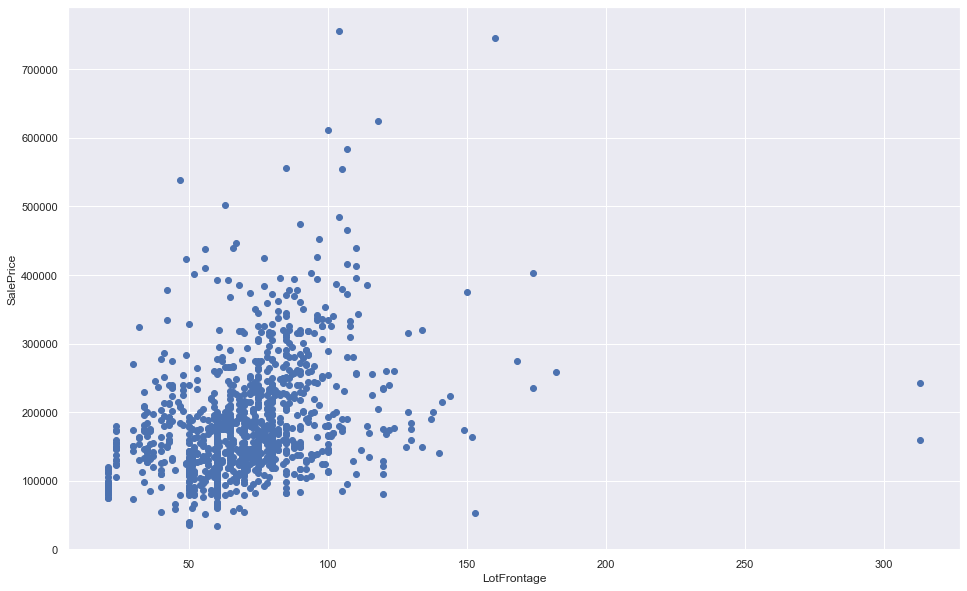

In [65]:
# LotFrontage - price, before imputation
sns.set()
plt.figure(figsize=(16, 10))
plt.scatter(df["LotFrontage"], df["SalePrice"])
plt.xlabel("LotFrontage")
plt.ylabel("SalePrice")


In [45]:
# FireplaceQu - price, before imputation
sns.set()
fp_dict = {}
for _v in df["FireplaceQu"].unique():
    print(_v)
    if pd.isnull(_v):
        _df = df[df["FireplaceQu_missing"]==True]
        fp_dict["nan"] = _df["SalePrice"].values
    else:
        _df = df[df["FireplaceQu"]==_v]
        fp_dict[_v] = _df["SalePrice"].values
fp_dict

nan
TA
Gd
Fa
Ex
Po


{'nan': array([208500, 143000, 129500, 144000, 132000,  90000, 159000, 139000,
        134800,  68500,  40000, 149350, 179900, 145000, 109000,  82000,
        144000, 130250, 141000, 249700, 113000, 127000, 177000, 110000,
        172500, 196500, 124900, 158000, 101000, 140000, 219500, 226000,
         80000, 129500, 144900, 107400,  91000, 135750, 127000, 136500,
        110000, 153500, 126500, 164500,  85000, 123600, 109900,  98600,
        163500, 204750, 214000,  94750,  83000, 128950, 118964, 198900,
        100000, 115000, 115000, 136900, 155000, 100000, 136000, 153900,
         84500, 150000, 150750, 220000, 171000, 231500, 260000, 166000,
        204000, 125000, 130000, 105000, 141000, 115000, 122000, 125000,
         79000, 109500, 162500, 103200, 152000, 127500, 128500, 100000,
        200000, 127000, 173000, 135000, 184000, 192000, 130000, 127000,
        104000, 140000, 112000, 110000, 180500, 145000,  98000, 186000,
        156000, 161750, 210000, 107000, 167240, 204900,  

[Text(0, 0, 'nan'),
 Text(0, 0, 'TA'),
 Text(0, 0, 'Gd'),
 Text(0, 0, 'Fa'),
 Text(0, 0, 'Ex'),
 Text(0, 0, 'Po')]

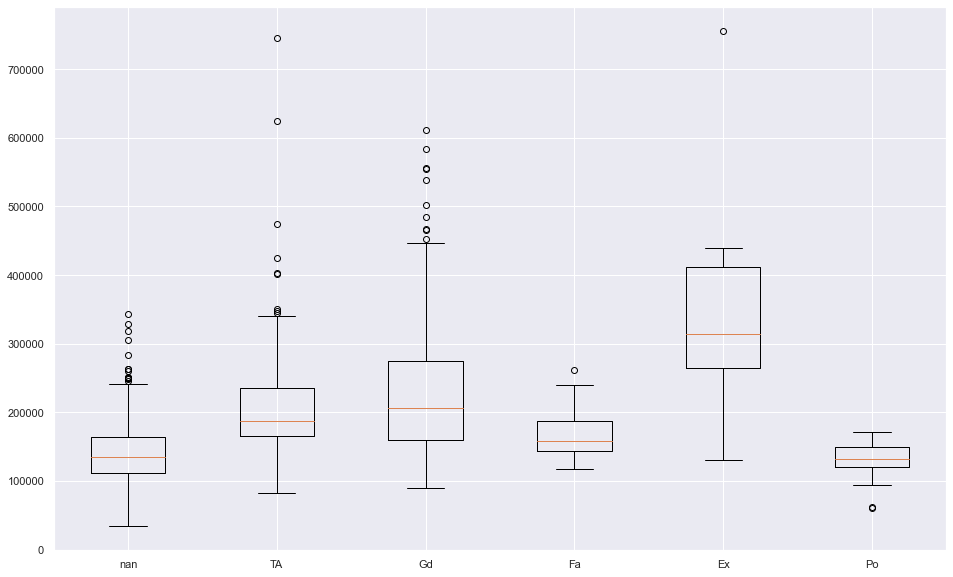

In [50]:
fig, ax = plt.subplots(figsize=(16, 10))
ax.boxplot(fp_dict.values())
ax.set_xticklabels(fp_dict.keys())

In [36]:

df[df["FireplaceQu_missing"]==True]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotFrontage_missing,FireplaceQu_missing,LotFrontage_mean,FireplaceQu_mode
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,2,2008,WD,Normal,208500,False,True,65.000000,Gd
5,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,...,700,10,2009,WD,Normal,143000,False,True,85.000000,NaN
10,20,RL,70.0,11200,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,2,2008,WD,Normal,129500,False,True,70.000000,NaN
12,20,RL,NaN,12968,Pave,NaN,IR2,Lvl,AllPub,Inside,...,0,9,2008,WD,Normal,144000,True,True,70.049958,NaN
15,45,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,7,2007,WD,Normal,132000,False,True,51.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1452,180,RM,35.0,3675,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,5,2006,WD,Normal,145000,False,True,35.000000,NaN
1453,20,RL,90.0,17217,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,7,2006,WD,Abnorml,84500,False,True,90.000000,NaN
1454,20,FV,62.0,7500,Pave,Pave,Reg,Lvl,AllPub,Inside,...,0,10,2009,WD,Normal,185000,False,True,62.000000,NaN
1458,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,4,2010,WD,Normal,142125,False,True,68.000000,NaN


Impute

In [57]:
def impute_rand(df_input, column):
    print("imputing " + column)
    result = df_input.copy(deep=True)
#     col_avg = df_input[column].mean()
#     col_std = df_input[column].std()
#     col_null_count = df_input[column].isnull().sum()
#     print("{}, {}, {}".format(col_avg - col_std, col_avg + col_std, col_null_count))
#     if col_null_count >= len()
#     col_null_random_list = np.random.randint(col_avg - col_std, col_avg + col_std, size=col_null_count)
#     result[column][np.isnan(df_input[column])] = col_null_random_list
#     result[column] = result[column].astype(int)
    imputer = KNNImputer(n_neighbors=2)
    result[column] = imputer.fit_transform(result[column].values.reshape(-1, 1)).reshape(1, -1)[0]
    
    return result

def impute_mode(df_input, column):
    result = df_input.copy(deep=True)
    col_mode = df_input[column].mode()
    result[column][result[result[column].isna() == True].index] = col_mode[0]
    return result

def KNN_impute(df_input):
    imputer = KNNImputer(n_neighbors=2)
    
    
num_impute_col = ['LotFrontage']
ctg_impute_col = ['Electrical']
ctg_constant_col = ['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','FireplaceQu','Fence', 
                    'GarageType','GarageFinish','GarageQual','GarageCond', 'PoolQC', 'MiscFeature', 'Alley']
# df_clean = df.copy(deep=True)
# for col in num_impute_col:
#     df_clean = impute_rand(df_clean, col)
# for col in ctg_impute_col:
#     df_clean = impute_mode(df_clean, col)
# for col in ctg_constant_col:
#     df_clean[col].fillna('not equipped', inplace=True)

# # add total area feature
# df_clean['TotalSF'] = df_clean['TotalBsmtSF'] + df_clean['1stFlrSF'] + df_clean['2ndFlrSF']

df["LotFrontage_mean"] = df["LotFrontage"].fillna(df["LotFrontage"].mean())
df["FireplaceQu_mode"] = df["FireplaceQu"].fillna(df["FireplaceQu"].mode()[0])

Text(0, 0.5, 'SalePrice')

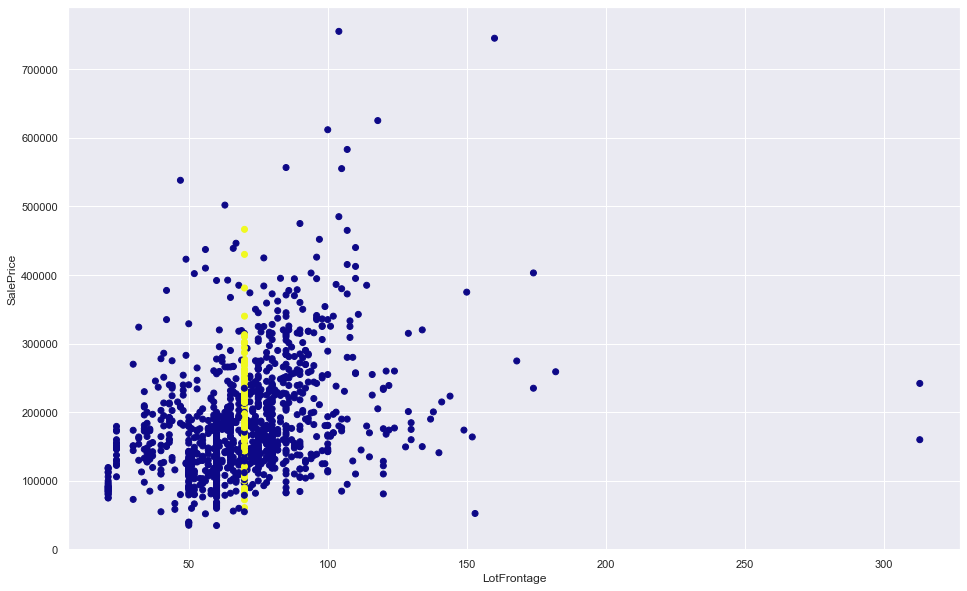

In [66]:
plt.figure(figsize=(16, 10))
plt.scatter(df["LotFrontage_mean"], df["SalePrice"], c=df["LotFrontage_missing"], cmap='plasma',)
plt.xlabel("LotFrontage")
plt.ylabel("SalePrice")

In [59]:
df["FireplaceQu_mode"].unique()

array(['Gd', 'TA', 'Fa', 'Ex', 'Po'], dtype=object)

Gd
TA
Fa
Ex
Po


[Text(0, 0, 'Gd'),
 Text(0, 0, 'TA'),
 Text(0, 0, 'Fa'),
 Text(0, 0, 'Ex'),
 Text(0, 0, 'Po')]

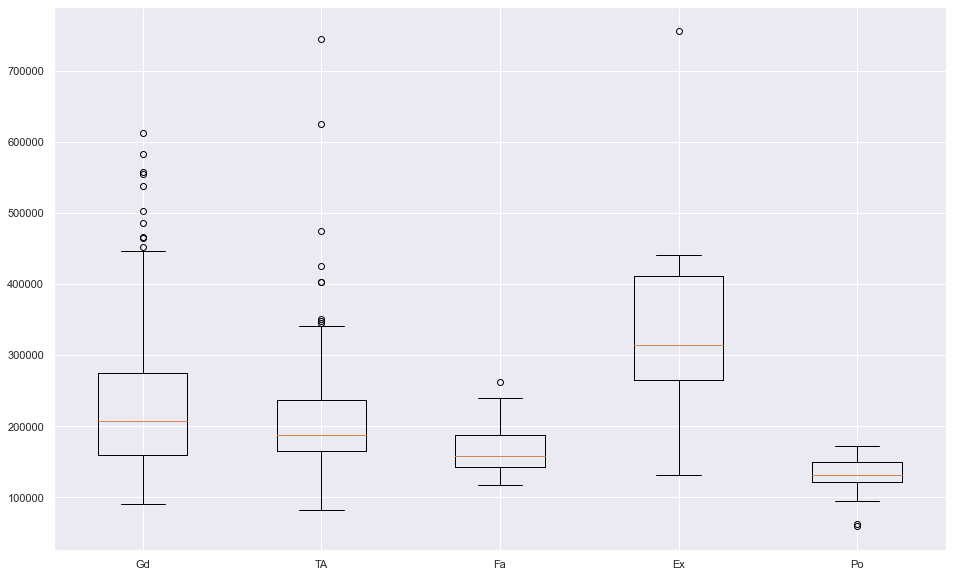

In [61]:
# FireplaceQu - price, before imputation
sns.set()
fp_dict2 = {}
for _v in df["FireplaceQu_mode"].unique():
    print(_v)
    if pd.isnull(_v):
        _df = df[df["FireplaceQu_missing"]==True]
        fp_dict2["nan"] = _df["SalePrice"].values
    else:
        _df = df[df["FireplaceQu"]==_v]
        fp_dict2[_v] = _df["SalePrice"].values

fig, ax = plt.subplots(figsize=(16, 10))
ax.boxplot(fp_dict2.values())
ax.set_xticklabels(fp_dict2.keys())